In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sns.set_theme()
gc.enable()

# Aggregating Bureau Balance

In [2]:
bureau_balance=pd.read_csv('bureau_balance.csv')
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
bureau_balance.shape

(27299925, 3)

In [4]:
bureau_balance['STATUS'].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

In [5]:
bureau_balance_agg=bureau_balance[['SK_ID_BUREAU', 'STATUS']].value_counts().unstack().replace(np.nan, 0).reset_index()
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0


In [6]:
bureau_balance_agg['TOTAL']=bureau_balance_agg.drop('SK_ID_BUREAU', axis=1).sum(axis=1)
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,0,1,2,3,4,5,C,X,TOTAL
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,97.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,83.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0


In [7]:
bureau_balance_agg.rename(columns={'0': 'STATUS_NO_DPD', '1': 'STATUS_<31DPD', '2': 'STATUS_<61DPD', '3': 'STATUS_<91DPD', 
                                   '4': 'STATUS_<121DPD', '5': 'STATUS_>120DPD',
                                   'C': 'STATUS_CLOSED', 'X': 'STATUS_NA', 'TOTAL': 'STATUS_TOTAL'}, inplace=True)
bureau_balance_agg.head()

STATUS,SK_ID_BUREAU,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,5001709,0.0,0.0,0.0,0.0,0.0,0.0,86.0,11.0,97.0
1,5001710,5.0,0.0,0.0,0.0,0.0,0.0,48.0,30.0,83.0
2,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
4,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0


# Dealing with main Bureau data

In [8]:
del bureau_balance
bureau=pd.read_csv('bureau.csv')
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


#### Merging with aggregated bureau balance data

In [9]:
bureau['SK_ID_BUREAU'].unique().shape, bureau_balance_agg['SK_ID_BUREAU'].unique().shape

((1716428,), (817395,))

In [10]:
combined_data=pd.merge(left=bureau, right=bureau_balance_agg, how='left', on='SK_ID_BUREAU')
combined_data.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_ANNUITY,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
numerical_features=combined_data.select_dtypes(exclude='object').columns
categorical_features=combined_data.columns.difference(numerical_features)

## Numerical Features

In [12]:
numerical_frame=combined_data[numerical_features].copy()
numerical_frame.head()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,...,AMT_ANNUITY,STATUS_NO_DPD,STATUS_<31DPD,STATUS_<61DPD,STATUS_<91DPD,STATUS_<121DPD,STATUS_>120DPD,STATUS_CLOSED,STATUS_NA,STATUS_TOTAL
0,215354,5714462,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,-203,0,528.0,NaN,NaN,0,464323.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,-203,0,NaN,NaN,NaN,0,90000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
numerical_frame['SK_ID_CURR'].unique().shape

(305811,)

In [17]:
numerical_frame.replace(to_replace={'STATUS_NO_DPD': np.nan, 'STATUS_<31DPD': np.nan, 'STATUS_<61DPD': np.nan,'STATUS_<91DPD': np.nan,        
                                    'STATUS_<121DPD': np.nan, 'STATUS_>120DPD': np.nan, 'STATUS_CLOSED': np.nan, 'STATUS_NA': np.nan,           
                                    'STATUS_TOTAL': np.nan}, value=0, inplace=True)
numerical_frame.isnull().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
STATUS_NO_DPD                   0
STATUS_<31DPD                   0
STATUS_<61DPD                   0
STATUS_<91DPD                   0
STATUS_<121DPD                  0
STATUS_>120DPD                  0
STATUS_CLOSED                   0
STATUS_NA                       0
STATUS_TOTAL                    0
dtype: int64

### Agregating numerical data

In [92]:
bureau_agg=numerical_frame.groupby(by='SK_ID_CURR').agg(func=['count', 'min', 'max', 'median'])
cols=pd.Index(['_'.join(val) for val in bureau_agg.columns.to_flat_index()])
bureau_agg.columns=cols
bureau_agg.shape

(305811, 88)

In [93]:
drop_cols=['_'.join([val, 'count']) for val in numerical_frame.columns.difference(['SK_ID_CURR', 'SK_ID_BUREAU'])]
drop_cols+=['SK_ID_BUREAU_min', 'SK_ID_BUREAU_max', 'SK_ID_BUREAU_median']

bureau_agg.drop(labels=drop_cols, axis=1, inplace=True)
bureau_agg.reset_index(inplace=True)
bureau_agg.shape

(305811, 65)

In [94]:
main_data_id_target=pd.read_csv('application_train.csv', usecols=['SK_ID_CURR', 'TARGET'])
main_data_id_target.head()

,SK_ID_CURR,TARGET
0,100002,1
1,100003,0
2,100004,0
3,100006,0
4,100007,0


#### Combining target to bureau agg

In [95]:
bureau_agg_target=pd.merge(left=bureau_agg, right=main_data_id_target, on='SK_ID_CURR', how='inner')
bureau_agg_target.shape

(263491, 66)

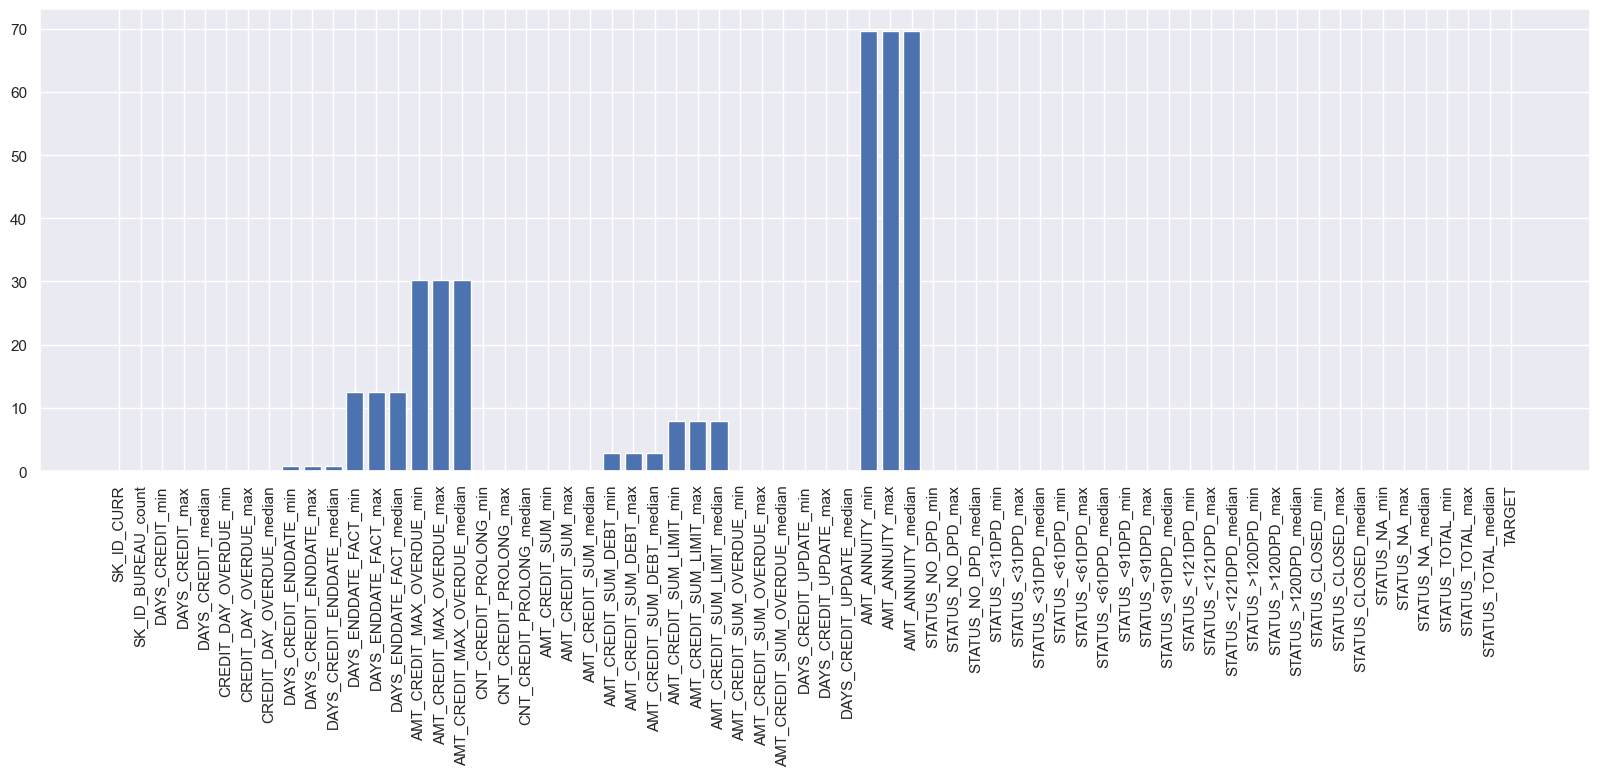

In [97]:
plot_data=bureau_agg_target.isnull().sum()*100/bureau_agg_target.shape[0]
# plot_data=plot_data[plot_data>0]
ax=plt.axes()
ax.bar(plot_data.index, plot_data.values)
ax.tick_params(axis='x', rotation=90)
ax.get_figure().set_size_inches(20, 6)

### Functions

In [73]:
def plot_hist_box(data, feature):
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [74]:
def plot_hist_default_pct(feature, dataframe, bins):
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [75]:
def calc_iqr(feature, data):
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [76]:
def plot_kde_vs_target(feature, main_data):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [79]:
def plot_all_numeric_kde(main_data, numerical_features):
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [77]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [78]:
def median_vs_target(feature, data):
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [ ]:
# plot_all_numeric_kde(bureau_agg_target, bureau_agg_target.columns)